In [2]:
# toy abm model from scratch bc why make things easy when they can be hard
# hard like me

In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [79]:
test = np.zeros((4,2))
test[0][1] =1 
test[1][1] = 0
test

array([[0., 1.],
       [0., 0.],
       [0., 0.],
       [0., 0.]])

In [80]:
i_satisfied(test, 0,0,0,0.5)


True

In [420]:
def i_satisfied(board, x, y, color, threshold):
    # check if location is open 
    if board[x][y] != 0:
        return False
    
    # check if i is satisfied with that location: check surrounding pieces (mimicking the segregation model)
    num_good_neighbors = 0
    num_bad_neighbors = 0
    
    for j in range(max(x-1,0), min(x+1+1,len(board[0]))):
        for k in range(max(y-1,0), min(y+1+1,len(board[1]))):
            
            if j == x and k == y:
                continue # skip current location
                
            if board[j][k] == color: 
                num_good_neighbors += 1
                
            elif board[j][k] != 0:
                num_bad_neighbors += 1
                
    if num_good_neighbors == 0 and (num_bad_neighbors == 0):
        return True # empty slot
    
    ratio = num_good_neighbors/(num_bad_neighbors+num_good_neighbors)
    result = ratio >= threshold
    return result
            
    

In [421]:
i = 0
length = 50
width = 50
board = np.zeros((length,width))
threshold = 0.5

rng = np.random.default_rng() # np.random.randint is not recommended for "new code"

num_successes = 0
num_iter = length*width

for i in range(1,num_iter):
    # set color of i
    if i % 2 == 0:
        color = '1'
    else:
        color = '5'
        
    # until i finds an open satisfactory spot or gets tired, loop
    tries = 5
    while tries >= 0:
        # i chooses its location
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=length)
        
        if i_satisfied(board, x, y, color, threshold): 
            board[x][y] = color
            num_successes += 1
            break
        tries -= 1

print(num_successes, num_iter)

474 2500


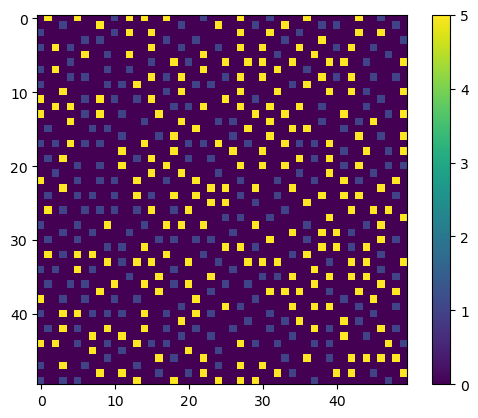

In [422]:
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()

In [391]:
i_satisfied(board, 1,3,1,0.5)

False

In [392]:
test = np.zeros((4,4))

In [393]:
test[0,1] = 1
test

array([[0., 1., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

In [394]:
i_satisfied(test, 0,0,0,0.5)

True

2348 2500


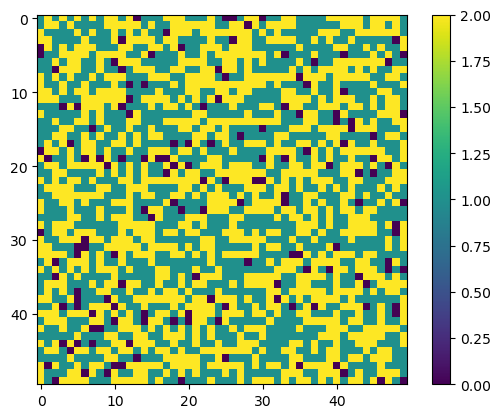

iteration:  100  num unsatisfied:  0.03492333901192504
iteration:  200  num unsatisfied:  0.022998296422487224
iteration:  300  num unsatisfied:  0.014906303236797274
iteration:  400  num unsatisfied:  0.011073253833049404
iteration:  500  num unsatisfied:  0.008943781942078365
iteration:  600  num unsatisfied:  0.011073253833049404
iteration:  700  num unsatisfied:  0.010647359454855196


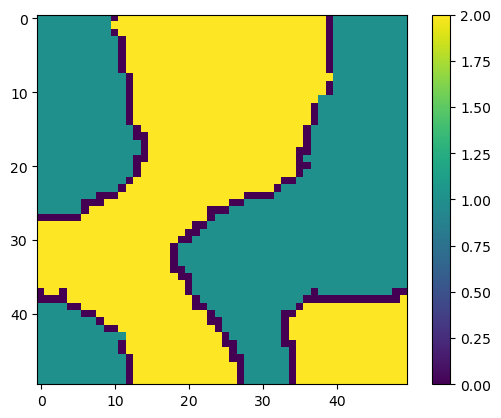

In [424]:
class Agent():
    def __init__(self, color):
        self.color = color
        self.satisfied = False
        self.in_valid_spot = True
        self.x = None
        self.y = None
    def update_position(self, x, y):
        self.x = x
        self.y = y
        

def agent_satisfied(board, x, y, color, threshold):
    
    # check if agent is satisfied with that location: check surrounding pieces (mimicking the segregation model)
    num_good_neighbors = 0
    num_bad_neighbors = 0
    
    for j in range(max(x-1,0), min(x+1+1,len(board[0]))):
        for k in range(max(y-1,0), min(y+1+1,len(board[1]))):
            
            if j == x and k == y:
                continue # skip current location
                
            if board[j][k] == color: 
                num_good_neighbors += 1
                
            elif board[j][k] != 0:
                num_bad_neighbors += 1
                
    if num_good_neighbors == 0 and num_bad_neighbors == 0:
        return True # empty slot
    
    ratio = num_good_neighbors/(num_bad_neighbors+num_good_neighbors)
    result = ratio >= threshold
    return result

def move_agents(board, placed_agents, threshold):
    
    for ag in placed_agents:

        # check agent satisfaction and update
        ag.satisfied = agent_satisfied(board, ag.x, ag.y, ag.color, threshold)

        if ag.satisfied:
            continue

        # not satisfied so move to a random *empty* location
        tries = 10
        width = len(board[0])
        length = len(board[1])
        while tries > 0:

            # i chooses its location
            x = rng.integers(0, high=width)
            y = rng.integers(0, high=length)

            if board[x][y] == 0: 
                board[x][y] = ag.color
                board[ag.x][ag.y] = 0
                ag.update_position(x,y)
                break

            tries -= 1
    return board, placed_agents


# fill board with random populations
i = 0
length = 50
width = 50
board = np.zeros((length,width))
threshold = 0.7

rng = np.random.default_rng() # np.random.randint is not recommended for "new code"

num_successes = 0
num_iter = length*width

# make a bunch of agents: change modulus to make more classes (%2 is binary, %3 is trinary etc)
agents = [Agent(i%2 + 1) for i in range(num_iter)]

placed_agents = []

for ag in agents:
        
    # until i finds an open satisfactory spot or gets tired, loop
    tries = 10
    while tries > 0:
        
        # i chooses its location
        x = rng.integers(0, high=width)
        y = rng.integers(0, high=length)
        
        if board[x][y] == 0: 
            board[x][y] = ag.color
            ag.update_position(x,y)
            num_successes += 1
            placed_agents.append(ag)
            break
            
        tries -= 1
        


print(num_successes, num_iter)
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()


            
num_unsatisfied_agents = len(placed_agents)
iter_count = 0
unsatisfaction_log = []
while num_unsatisfied_agents > 5:
    # move agents around if unsatisfied
    move_agents(board, placed_agents, threshold) 
    
    num_unsatisfied_agents = 0
    # after moving, evaluate satisfaction
    for ag in placed_agents:
        ag.satisfied = agent_satisfied(board, ag.x, ag.y, ag.color, threshold)
        if not ag.satisfied:
            num_unsatisfied_agents += 1
    unsatisfaction_log.append(num_unsatisfied_agents / len(placed_agents))
    iter_count += 1
    if iter_count%100 == 0:
        print("iteration: ", iter_count, " num unsatisfied: ", num_unsatisfied_agents / len(placed_agents))
    if (unsatisfaction_log[0] - unsatisfaction_log[-1]) <= 0.03 and iter_count > 1000:
        print("no meaningful change in 1000 iterations, aborting")
        break
    #print("moving")
    
    
plt.figure()
plt.imshow(board)
plt.colorbar()
plt.show()